# Figure 1:  SMYLE & DPLE Global Sea Level Pressure ACC Maps
- This notebook also generates Figs. B01, B03

In [15]:
%load_ext autoreload
%autoreload 2
import os
import xarray as xr 
import numpy as np  
import cftime
import copy
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import xesmf as xe
import xskillscore as xs
%matplotlib inline

# import ESP-Lab modules
#from esp_lab import data_access_smyle.py as data_access
from esp_lab import data_access_e3sm as data_access
from esp_lab import data_access_obs as obs_access
from esp_lab import stats

# import plotting and other utilities from esp_lab.utils (formerly SMYLEutils)
from esp_lab.utils import calendar_utils as cal
from esp_lab.utils import mapplot_utils as maps
from esp_lab.utils import colorbar_utils as cbars
from esp_lab.utils import regrid_utils as regrid


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
import dask
from dask.distributed import (
    wait,
    get_client
)
dask.__version__

'2026.3.0'

## Preprocessing:  Data I/O using Dask

### Create Dask Cluster

In [17]:
def get_ClusterClient(cluster_type='local', workers=4):
    """
    Create a Dask Cluster and Client based on the machine environment.
    cluster_type options: 'local', 'casper_pbs', 'slurm'
    """
    import dask
    from dask.distributed import Client
    
    # Optional global dask config
    dask.config.set({'array.slicing.split_large_chunks': True})

    if cluster_type == 'casper_pbs':
        # Specific to NCAR's Casper machine
        from dask_jobqueue import PBSCluster
        cluster = PBSCluster(
            cores=1,
            memory='20GB',
            processes=1,
            queue='casper',
            resource_spec='select=1:ncpus=1:mem=20GB',
            project='NCGD0011',
            walltime='02:00:00',
            interface='ib0'
        )
        dask.config.set({
            'distributed.dashboard.link':
            'https://jupyterhub.hpc.ucar.edu/stable/user/{USER}/proxy/{port}/status'
        })
        client = Client(cluster)
        cluster.scale(30)
        
    elif cluster_type == 'slurm':
        from dask_jobqueue import SLURMCluster
        cluster = SLURMCluster(
            cores=4,
            processes=1,
            memory="16GB",
            walltime="02:00:00"
            # queue="compute", 
            # project="my_project" 
        )
        client = Client(cluster)
        cluster.scale(workers)
        
    elif cluster_type == 'local':
        from dask.distributed import LocalCluster
        cluster = LocalCluster(n_workers=workers)
        client = Client(cluster)
        
    else:
        raise ValueError(f"Unknown cluster_type: {cluster_type}")

    return cluster, client

# Set this to 'casper_pbs' when on NCAR Casper, or 'local' on your PC
machine_env = os.environ.get('CLUSTER_TYPE', 'local') 

try:
    client = get_client()
    print(client)
except ValueError:
    print("No active client")
try:
    client.close()
    cluster.close()
except:
    pass

cluster, client = get_ClusterClient(cluster_type=machine_env, workers=30)

<Client: 'tcp://127.0.0.1:45977' processes=30 threads=270, memory=502.97 GiB>


/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.10/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 33233 instead
  warnings.warn(


In [18]:
cluster

LocalCluster(b905a974, 'tcp://127.0.0.1:34279', workers=30, threads=270, memory=502.97 GiB)

### Read in EAM monthly data; Convert to Seasonal averages (DJF, MAM, JJA, SON)
- Chosen field is returned as a dask array with leading dimensions of Y (initialization year), M (ensemble member), and L (lead season). For example, for November starts, L=1 corresponds to first DJF season.
- "time" which gives prediction verification time (centered time for a given season) is also dimensioned with (Y,L)

In [19]:
%%time
# E3SM-May PSL data
# process all 10 ensemble members, all start dates from 1980-2014:
field = "PSL"
data_dir = "/pscratch/sd/z/zhan391/e3sm_project/E3SMv3_S2D"
case_prefix = "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL"
case_nens = 10    # total ensemble members for each lead-time simulation
case_nlead = 24   # total simulation months starting from each init
engine = "netcdf4" #"netcdf4" #or scipy for older format 

lead_years = np.arange(1980, 1984, 1)
lead_month = 5 # or [5, 11]
members = [f"EN{i:02d}" for i in range(case_nens)]

realm = "atm"         # post-processed model component (atm, lnd, rof, ocean, sea-ice)
grid = "180x360_aave" # post-processed grid (e3sm_diags)
freq = "monthly"      # model output frequency 
ts_split = "2yr"      # post-processed # of years in each file 

# all ensemble members are present for an initialization
require_all_members = True
verify_field_name = True
verify_coverage = True

init_tags = data_access.build_init_tags(lead_years, lead_month)
chunk = {}
print(init_tags)
print(case_prefix)

e3smle05 = data_access.get_monthly_data(
    data_dir=data_dir,
    case_prefix=case_prefix,
    members=members,
    init_tags=init_tags,
    field=field,
    nlead=case_nlead,
    chunks=chunk,
    realm=realm,
    grid=grid,
    freq=freq,
    ts_split=ts_split,
    require_all_members=require_all_members,
    verify_field_name=verify_field_name,
    verify_coverage=verify_coverage,
    engine=engine,
)

e3smle05.nbytes / 1e9  # GB

# debug 
print(e3smle05)
print(e3smle05.dims)
print(e3smle05.Y.values)
print(e3smle05.L.values[:5], e3smle05.L.values[-5:])
print(e3smle05.time.isel(Y=0, L=slice(0, 3)).values)


['1980050100', '1981050100', '1982050100', '1983050100']
WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL
<xarray.Dataset> Size: 249MB
Dimensions:  (Y: 4, L: 24, M: 10, lat: 180, lon: 360)
Coordinates:
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * L        (L) int64 192B 1 2 3 4 5 6 7 8 9 10 ... 16 17 18 19 20 21 22 23 24
  * Y        (Y) <U10 160B '1980050100' '1981050100' '1982050100' '1983050100'
  * M        (M) <U4 160B 'EN00' 'EN01' 'EN02' 'EN03' ... 'EN07' 'EN08' 'EN09'
Data variables:
    time     (Y, L) object 768B dask.array<chunksize=(1, 24), meta=np.ndarray>
    PSL      (Y, L, M, lat, lon) float32 249MB dask.array<chunksize=(1, 24, 1, 180, 360), meta=np.ndarray>
FrozenMappingWarningOnValuesAccess({'Y': 4, 'L': 24, 'M': 10, 'lat': 180, 'lon': 360})
['1980050100' '1981050100' '1982050100' '1983050100']
[1 2 3 4 5] [20 21 22 23 24]
[cftime.DatetimeNoLeap(1980, 

In [20]:
%%time
# E3SM-Nov PSL data
# process all 10 ensemble members, all start dates from 1980-2014:
field = "PSL"
data_dir = "/pscratch/sd/z/zhan391/e3sm_project/E3SMv3_S2D"
case_prefix = "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL"
case_nens = 10    # total ensemble members for each lead-time simulation
case_nlead = 24   # total simulation months starting from each init
engine = "netcdf4" # or scipy for older format 

lead_years = np.arange(1980, 1984, 1)
lead_month = 11 # or [5, 11]
members = [f"EN{i:02d}" for i in range(case_nens)]

realm = "atm"         # post-processed model component (atm, lnd, rof, ocean, sea-ice)
grid = "180x360_aave" # post-processed grid (e3sm_diags)
freq = "monthly"      # model output frequency 
ts_split = "2yr"      # post-processed # of years in each file 

# all ensemble members are present for an initialization
require_all_members = True
verify_field_name = True
verify_coverage = True

init_tags = data_access.build_init_tags(lead_years, lead_month)
chunk = {}
print(init_tags)
print(case_prefix)

e3smle11 = data_access.get_monthly_data(
    data_dir=data_dir,
    case_prefix=case_prefix,
    members=members,
    init_tags=init_tags,
    field=field,
    nlead=case_nlead,
    chunks=chunk,
    realm=realm,
    grid=grid,
    freq=freq,
    ts_split=ts_split,
    require_all_members=require_all_members,
    verify_field_name=verify_field_name,
    verify_coverage=verify_coverage,
    engine = engine
)

e3smle11.nbytes / 1e9  # GB

# debug 
print(e3smle11)
print(e3smle11.dims)
print(e3smle11.Y.values)
print(e3smle11.L.values[:5], e3smle11.L.values[-5:])
print(e3smle11.time.isel(Y=0, L=slice(0, 3)).values)

['1980110100', '1981110100', '1982110100', '1983110100']
WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL
<xarray.Dataset> Size: 249MB
Dimensions:  (Y: 4, L: 24, M: 10, lat: 180, lon: 360)
Coordinates:
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * L        (L) int64 192B 1 2 3 4 5 6 7 8 9 10 ... 16 17 18 19 20 21 22 23 24
  * Y        (Y) <U10 160B '1980110100' '1981110100' '1982110100' '1983110100'
  * M        (M) <U4 160B 'EN00' 'EN01' 'EN02' 'EN03' ... 'EN07' 'EN08' 'EN09'
Data variables:
    time     (Y, L) object 768B dask.array<chunksize=(1, 24), meta=np.ndarray>
    PSL      (Y, L, M, lat, lon) float32 249MB dask.array<chunksize=(1, 24, 1, 180, 360), meta=np.ndarray>
FrozenMappingWarningOnValuesAccess({'Y': 4, 'L': 24, 'M': 10, 'lat': 180, 'lon': 360})
['1980110100' '1981110100' '1982110100' '1983110100']
[1 2 3 4 5] [20 21 22 23 24]
[cftime.DatetimeNoLeap(1980, 

### Store datasets to disk for quicker processing next time (note this takes >30 minutes)

In [21]:
%%time
outdir = '/pscratch/sd/z/zhan391/e3sm_project/E3SMv3_S2D/s2d_diag/E3SMLE'
os.makedirs(outdir, exist_ok=True)

outname = f"E3SMLE05_{field}_N{case_nens:02d}_M{case_nlead:02d}_seas.nc"
outfile = os.path.join(outdir, outname)
force_rewrite = True

if os.path.exists(outfile) and not force_rewrite:
    e3smle05_seas = xr.open_dataset(outfile)
else:
    if os.path.exists(outfile):
        os.remove(outfile)

    e3smle05_seas = cal.mon_to_seas_dask(e3smle05).persist()
    daskout = wait(e3smle05_seas)

    e3smle05_seas.to_netcdf(outfile)

# debug 
print(e3smle05_seas)
print(e3smle05_seas.dims)
print(e3smle05_seas.Y.values)
print(e3smle05_seas.L.values[:5], e3smle05_seas.L.values[-5:])
print(e3smle05_seas.time.isel(Y=0, L=slice(0, 3)).values)


<xarray.Dataset> Size: 83MB
Dimensions:  (lon: 360, lat: 180, L: 8, Y: 4, M: 10)
Coordinates:
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * L        (L) int64 64B 3 6 9 12 15 18 21 24
  * Y        (Y) <U10 160B '1980050100' '1981050100' '1982050100' '1983050100'
  * M        (M) <U4 160B 'EN00' 'EN01' 'EN02' 'EN03' ... 'EN07' 'EN08' 'EN09'
Data variables:
    PSL      (Y, L, M, lat, lon) float32 83MB dask.array<chunksize=(1, 8, 1, 90, 180), meta=np.ndarray>
    time     (Y, L) object 256B dask.array<chunksize=(1, 8), meta=np.ndarray>
FrozenMappingWarningOnValuesAccess({'lon': 360, 'lat': 180, 'L': 8, 'Y': 4, 'M': 10})
['1980050100' '1981050100' '1982050100' '1983050100']
[ 3  6  9 12 15] [12 15 18 21 24]
[cftime.DatetimeNoLeap(1980, 7, 15, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1980, 10, 15, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1981, 1, 1

In [22]:
%%time
outdir = '/pscratch/sd/z/zhan391/e3sm_project/E3SMv3_S2D/s2d_diag/E3SMLE'
os.makedirs(outdir, exist_ok=True)

outname = f"E3SMLE11_{field}_N{case_nens:02d}_M{case_nlead:02d}_seas.nc"
outfile = os.path.join(outdir, outname)
force_rewrite = True

if os.path.exists(outfile) and not force_rewrite:
    e3smle11_seas = xr.open_dataset(outfile)
else:
    if os.path.exists(outfile):
        os.remove(outfile)

    e3smle11_seas = cal.mon_to_seas_dask(e3smle11).persist()
    daskout = wait(e3smle11_seas)

    e3smle11_seas.to_netcdf(outfile)

# debug 
print(e3smle11_seas)
print(e3smle11_seas.dims)
print(e3smle11_seas.Y.values)
print(e3smle11_seas.L.values[:5], e3smle11_seas.L.values[-5:])
print(e3smle11_seas.time.isel(Y=0, L=slice(0, 3)).values)


<xarray.Dataset> Size: 83MB
Dimensions:  (lon: 360, lat: 180, L: 8, Y: 4, M: 10)
Coordinates:
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * L        (L) int64 64B 3 6 9 12 15 18 21 24
  * Y        (Y) <U10 160B '1980110100' '1981110100' '1982110100' '1983110100'
  * M        (M) <U4 160B 'EN00' 'EN01' 'EN02' 'EN03' ... 'EN07' 'EN08' 'EN09'
Data variables:
    PSL      (Y, L, M, lat, lon) float32 83MB dask.array<chunksize=(1, 8, 1, 90, 180), meta=np.ndarray>
    time     (Y, L) object 256B dask.array<chunksize=(1, 8), meta=np.ndarray>
FrozenMappingWarningOnValuesAccess({'lon': 360, 'lat': 180, 'L': 8, 'Y': 4, 'M': 10})
['1980110100' '1981110100' '1982110100' '1983110100']
[ 3  6  9 12 15] [12 15 18 21 24]
[cftime.DatetimeNoLeap(1981, 1, 15, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1981, 4, 15, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1981, 7, 15

### Regrid Hindcast data
- Regrid all hindcast outputs onto a common regular latitude–longitude grid (e.g., 5°×5°) to ensure consistent comparison across datasets
- Support multiple source grid types: a. Unstructured grids (e.g., E3SM/CAM-SE ncol) and b. tructured lat–lon grids (e.g., CESM/CAM-FV or post-processed E3SM)
- Apply a two-step workflow for unstructured grids: 1. Remap from native ncol to structured lat–lon using precomputed sparse mapping weights and 2. Regrid from intermediate lat–lon to target grid

In [25]:
%%time
# regrid the data to a targeted grid for analysis 
target_dlat = 1.0 
target_dlon = 1.0 

destgrid = regrid.make_latlon_grid(dlat=target_dlat, dlon=target_dlon)
regrid_method = 'conservative'
regrid_periodic = True

################################################################################
# native E3SM unstructured data (dimension: ncol)
# mapping weight file (e.g., ne30 to 1x1 degree weights generated by NCO/ESMF)
# step 1: ncol -> mapped lat/lon grid
# step 2: prepare + regrid to final target grid
################################################################################
#dsw_weights = xr.open_dataset('map_ne30pg2_to_cmip6_180x360_aave.20200201.nc')
#e3smle_ll = regrid.remap_camse(e3smle_seas, dsw_weights)
#regridder = regrid.make_regridder(e3smle_ll, destgrid, method='conservative', periodic=True)
#e3smle_da = regridder(e3smle_ll[field])

################################################################################
# post-processed E3SM lat-lon data (dimension: lat,lon)
################################################################################
regridder = regrid.make_regridder(e3smle05_seas, destgrid, method=regrid_method, periodic=regrid_periodic)
e3smle05_da = regridder(e3smle05_seas[field])
print(e3smle05_da.shape)
print(e3smle05_da.dims)
print(e3smle05_da.Y.values)
print(e3smle05_da.L.values[:5], e3smle05_da.L.values[-5:])

regridder = regrid.make_regridder(e3smle11_seas, destgrid, method=regrid_method, periodic=regrid_periodic)
e3smle11_da = regridder(e3smle11_seas[field])
print(e3smle11_da.shape)
print(e3smle11_da.dims)
print(e3smle11_da.Y.values)
print(e3smle11_da.L.values[:5], e3smle11_da.L.values[-5:])

if field == "PSL":
    factor = 1e-2
    # Convert E3SM PSL from Pa → hPa
    e3smle05_da = e3smle05_da * factor
    e3smle05_da.attrs["units"] = "hPa"
    
    e3smle11_da = e3smle11_da * factor
    e3smle11_da.attrs["units"] = "hPa"
    

/global/homes/z/zhan391/.local/lib/python3.10/site-packages/xarray/core/computation.py:312: PerformanceWarning: Regridding is increasing the number of chunks by a factor of 6.0, you might want to specify sizes in `output_chunks` in the regridder call. Default behaviour is to preserve the chunk sizes from the input (90, 180).
  result_var = func(*data_vars)


(4, 8, 10, 181, 360)
('Y', 'L', 'M', 'lat', 'lon')
['1980050100' '1981050100' '1982050100' '1983050100']
[ 3  6  9 12 15] [12 15 18 21 24]
(4, 8, 10, 181, 360)
('Y', 'L', 'M', 'lat', 'lon')
['1980110100' '1981110100' '1982110100' '1983110100']
[ 3  6  9 12 15] [12 15 18 21 24]
CPU times: user 13.8 s, sys: 4.54 s, total: 18.3 s
Wall time: 14.3 s


/global/homes/z/zhan391/.local/lib/python3.10/site-packages/xarray/core/computation.py:312: PerformanceWarning: Regridding is increasing the number of chunks by a factor of 6.0, you might want to specify sizes in `output_chunks` in the regridder call. Default behaviour is to preserve the chunk sizes from the input (90, 180).
  result_var = func(*data_vars)


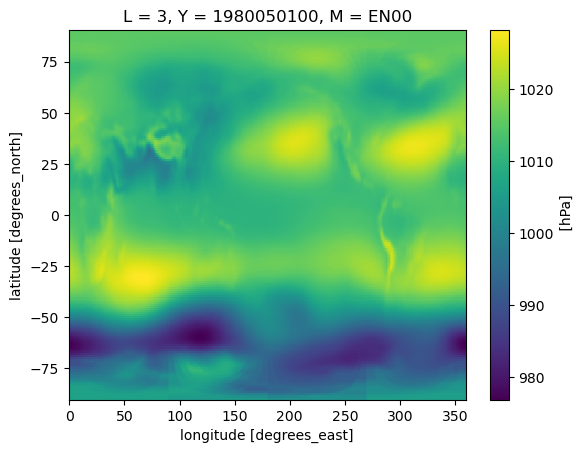

In [26]:
e3smle05_da.isel(Y=0, L=0, M=0).plot();

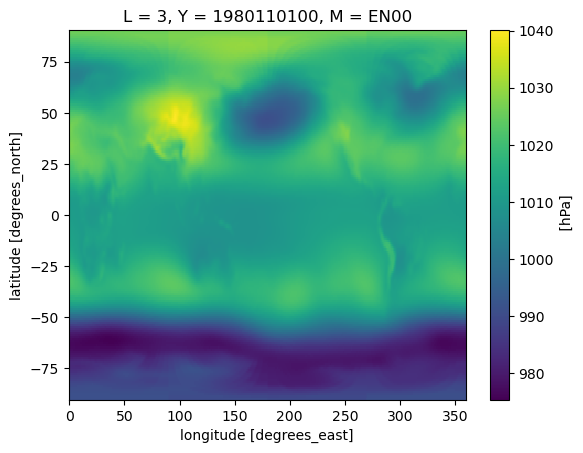

In [27]:
e3smle11_da.isel(Y=0, L=0, M=0).plot();

### Get Observational datasets
- Load observational datasets from the E3SM Diags archive (CMOR variables).
- Harmonize in time, variable naming, and space (regridding to a common grid).
- Provide consistent reference fields for hindcast evaluation.
- Compute OBS seasonal averages as a simple rolling mean
- Regrid to analysis grid 

In [28]:
%%time
obs_dir = '/global/cfs/cdirs/e3sm/e3sm_diags/obs_for_e3sm_diags/time-series'
obs_product = "ERA5" #"GPCP_v3.2"
obs_var = "psl" #sat_gauge_precip
obs_yrs = 1979
obs_yre = 2019

obs_era5 = obs_access.get_monthly_data(
    obs_dir=obs_dir,
    field=field,
    field_map={field: obs_var},
    product=obs_product,
    start_year=obs_yrs,
    end_year=obs_yre,
    verbose=True
)
#print(obs_era5)

#Compute OBS seasonal averages (simple rolling mean)
obs_era5_seas = obs_access.mon_to_seas_obs(
    obs_era5,
    var=obs_var,
    field_map={field: obs_var},
)
#print(obs_era5_seas)
regridder_obs = regrid.make_regridder(obs_era5, destgrid, method = regrid_method, periodic=regrid_periodic)
obs_era5_seas_rg = regridder_obs(obs_era5_seas)
print(obs_era5_seas_rg)

# Convert from Pa → hPa
factor = 1e-2
obs_era5_seas_rg = obs_era5_seas_rg * factor
obs_era5_seas_rg.attrs["units"] = "hPa"
print(obs_era5_seas_rg)


[OBS] Mapping field 'PSL' -> 'psl'
[OBS] Loading: /global/cfs/cdirs/e3sm/diagnostics/observations/Atm/time-series/ERA5/psl_197901_201912.nc
<xarray.DataArray (time: 490, lat: 181, lon: 360)> Size: 128MB
dask.array<astype, shape=(490, 181, 360), dtype=float32, chunksize=(246, 181, 360), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 4kB 1979-02-15 00:00:00 ... 2019-11-15 00:00:00
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
Attributes:
    regrid_method:  conservative
<xarray.DataArray (time: 490, lat: 181, lon: 360)> Size: 128MB
dask.array<mul, shape=(490, 181, 360), dtype=float32, chunksize=(246, 181, 360), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 4kB 1979-02-15 00:00:00 ... 2019-11-15 00:00:00
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 

/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.10/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 37.14 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


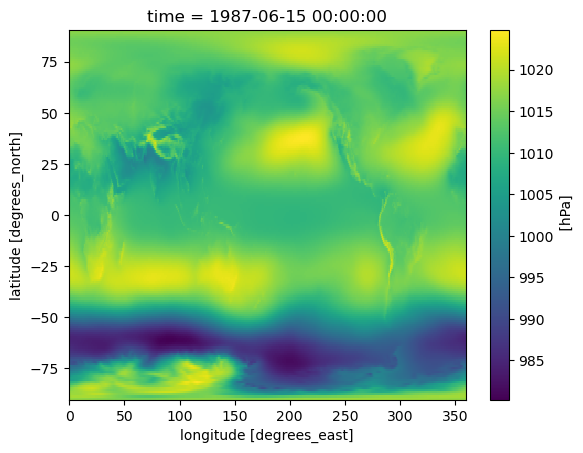

In [29]:
obs_era5_seas_rg.isel(time=100).plot()

# Skill Analysis

In [30]:
%%time
e3smle05_time = e3smle05_seas.time.load()
e3smle11_time = e3smle11_seas.time.load()

CPU times: user 44.2 ms, sys: 37.7 ms, total: 81.9 ms
Wall time: 89.5 ms


In [31]:
%%time
# Compute de-drifted anomalies from specified climatology
climy0 = 1980
climy1 = 1983
e3smle05_anom,e3smle05_clim = stats.remove_drift(e3smle05_da,e3smle05_time,climy0,climy1)
e3smle11_anom,e3smle11_clim = stats.remove_drift(e3smle11_da,e3smle11_time,climy0,climy1)

CPU times: user 35.2 ms, sys: 3.94 ms, total: 39.1 ms
Wall time: 40 ms


def check_remove_drift(da, da_time, anom, clim, climy0, climy1, name="case"):
    d1 = cftime.DatetimeNoLeap(climy0, 1, 1, 0, 0, 0)
    d2 = cftime.DatetimeNoLeap(climy1, 12, 31, 23, 59, 59)

    masked = da.where((da_time > d1) & (da_time < d2))
    clim_manual = masked.mean("M").mean("Y")
    anom_manual = da - clim_manual
    masked_anom = anom.where((da_time > d1) & (da_time < d2))

    print(f"=== {name} ===")
    print("raw dims :", da.dims, da.shape)
    print("anom dims:", anom.dims, anom.shape)
    print("clim dims:", clim.dims, clim.shape)

    xr.testing.assert_allclose(clim, clim_manual)
    xr.testing.assert_allclose(anom, anom_manual)
    print("manual reconstruction: PASS")

    resid = masked_anom.mean(("Y", "M"))
    print("max abs masked anomaly mean:", float(abs(resid).max(skipna=True)))

    nvalid = masked.notnull().sum(("Y", "M"))
    print("min valid samples per (L,lat,lon):", int(nvalid.min(skipna=True)))
    print("max valid samples per (L,lat,lon):", int(nvalid.max(skipna=True)))

    print("missing clim cells by lead:")
    print(clim.isnull().sum(("lat", "lon")))

check_remove_drift(e3smle05_da, e3smle05_time, e3smle05_anom, e3smle05_clim, 1980, 1983, "May")
check_remove_drift(e3smle11_da, e3smle11_time, e3smle11_anom, e3smle11_clim, 1980, 1983, "Nov")

In [33]:
%%time
# compute and save skill data 
outdir = '/pscratch/sd/z/zhan391/e3sm_project/E3SMv3_S2D/s2d_diag/E3SMLE'
os.makedirs(outdir, exist_ok=True)

force_compute = True
detrend = True

if detrend: 
    outname = f"{field}_skill_clim_{climy0}_{climy1}_detrend.nc"
else:
    outname = f"{field}_skill_clim_{climy0}_{climy1}.nc"
    
outfile = os.path.join(outdir, outname)

if os.path.exists(outfile) and not force_compute:
    skill_ds = xr.open_dataset(outfile).load()
else:
    if force_compute and os.path.exists(outfile):
        os.remove(outfile)
    # compute skill
    e3smle05_anom = e3smle05_anom.chunk({"Y": -1})
    e3smle11_anom = e3smle11_anom.chunk({"Y": -1})
    obs_era5_seas_rg = obs_era5_seas_rg.chunk({"time": -1})

    clim_start = cftime.DatetimeNoLeap(climy0, 1, 1)
    clim_end   = cftime.DatetimeNoLeap(climy1, 12, 31)

    e3smle05_skill = stats.compute_skill_seasonal(
        e3smle05_anom, e3smle05_time, obs_era5_seas_rg,
        clim_start, clim_end, 1, 8, resamp=0, detrend=detrend
    )
    e3smle11_skill = stats.compute_skill_seasonal(
        e3smle11_anom, e3smle11_time, obs_era5_seas_rg,
        clim_start, clim_end, 1, 8, resamp=0, detrend=detrend
    )
    
    # force computation once, then save
    skill_ds = xr.Dataset({
        "corr05": e3smle05_skill.corr,
        "pval05": e3smle05_skill.pval,
        "rmse05": e3smle05_skill.rmse,
        "msss05": e3smle05_skill.msss,
        "rpc05": e3smle05_skill.rpc,
        "sig_obs05": e3smle05_skill.sig_obs,
        "sig_sig05": e3smle05_skill.sig_sig,
        "sig_tot05": e3smle05_skill.sig_tot,
        "s2t05": e3smle05_skill.s2t,
    
        "corr11": e3smle11_skill.corr,
        "pval11": e3smle11_skill.pval,
        "rmse11": e3smle11_skill.rmse,
        "msss11": e3smle11_skill.msss,
        "rpc11": e3smle11_skill.rpc,
        "sig_obs11": e3smle11_skill.sig_obs,
        "sig_sig11": e3smle11_skill.sig_sig,
        "sig_tot11": e3smle11_skill.sig_tot,
        "s2t11": e3smle11_skill.s2t,
    }).compute()
    
    skill_ds.to_netcdf(outfile)

print(outfile)
print(skill_ds)

/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.10/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 45.66 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.10/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.10/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.10/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.div

/pscratch/sd/z/zhan391/e3sm_project/E3SMv3_S2D/s2d_diag/E3SMLE/PSL_skill_clim_1980_1983_detrend.nc
<xarray.Dataset> Size: 75MB
Dimensions:    (lat: 181, lon: 360, L: 8)
Coordinates:
  * lat        (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon        (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * L          (L) int64 64B 3 6 9 12 15 18 21 24
Data variables: (12/18)
    corr05     (L, lat, lon) float64 4MB 0.7802 0.7778 0.7788 ... nan nan nan
    pval05     (L, lat, lon) float64 4MB nan nan nan nan nan ... nan nan nan nan
    rmse05     (L, lat, lon) float64 4MB 0.6344 0.6379 0.6362 ... nan nan nan
    msss05     (L, lat, lon) float64 4MB 0.5976 0.5931 0.5952 ... nan nan nan
    rpc05      (L, lat, lon) float64 4MB 1.443 1.437 1.439 1.44 ... nan nan nan
    sig_obs05  (L, lat, lon) float64 4MB 2.059 2.061 2.063 ... 0.6451 0.6464
    ...         ...
    msss11     (L, lat, lon) float64 4MB 0.2232 0.2426 0.2427 ... nan nan nan
    rpc11   

### Compute resampled (10-member) E3SMLE Skill

<xarray.Dataset> Size: 42MB
Dimensions:    (lat: 181, lon: 360, L: 8)
Coordinates:
  * lat        (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon        (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * L          (L) int64 64B 3 6 9 12 15 18 21 24
Data variables: (12/18)
    corr05     (L, lat, lon) float32 2MB 0.426 0.4332 0.4346 ... nan nan nan
    pval05     (L, lat, lon) float64 4MB 0.574 0.5668 0.5654 ... nan nan nan
    rmse05     (L, lat, lon) float32 2MB 0.9194 0.9149 0.914 ... nan nan nan
    msss05     (L, lat, lon) float32 2MB 0.1546 0.1629 0.1646 ... nan nan nan
    rpc05      (L, lat, lon) float32 2MB 0.8954 0.9137 0.9166 ... nan nan nan
    sig_obs05  (L, lat, lon) float32 2MB 3.111 3.111 3.111 ... 0.7218 0.7225
    ...         ...
    msss11     (L, lat, lon) float32 2MB 0.2076 0.2302 0.2301 ... nan nan nan
    rpc11      (L, lat, lon) float32 2MB 8.044 7.705 7.706 7.708 ... nan nan nan
    sig_obs11  (L, lat, lon) float32 2

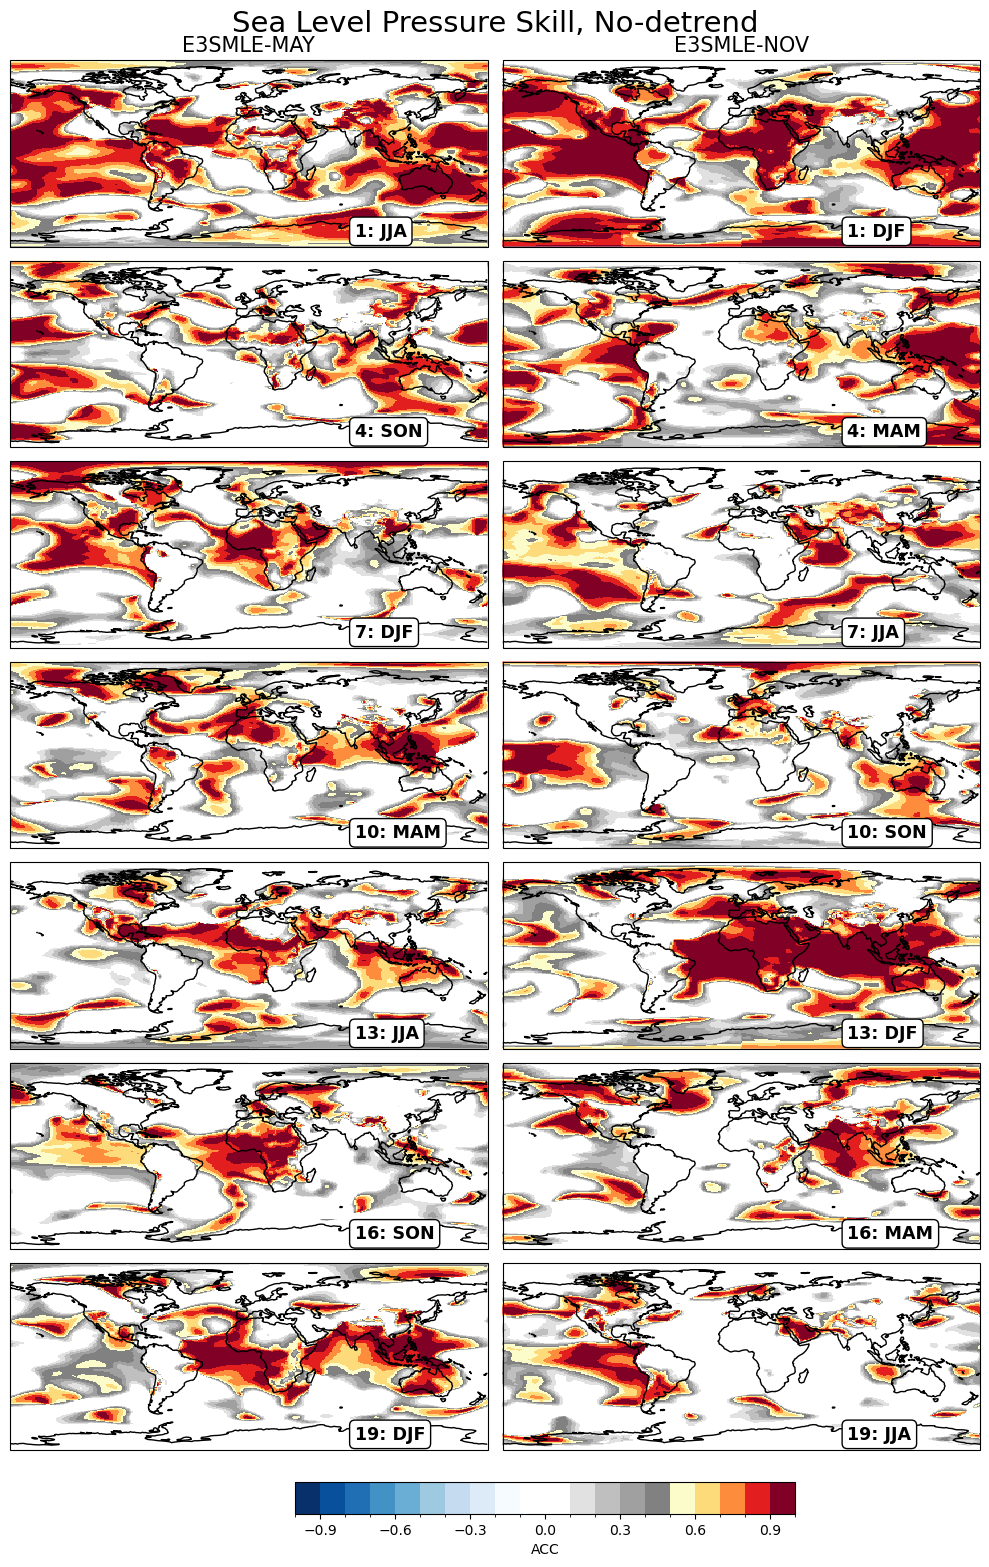

In [35]:
%%time
# read saved skill data 
outdir = '/pscratch/sd/z/zhan391/e3sm_project/E3SMv3_S2D/s2d_diag/E3SMLE'
detrend = False
sigon = False
siglvl = 0.1
mask_negacc = True # mask negative values for limited samples 

if detrend: 
    outname = f"{field}_skill_clim_{climy0}_{climy1}_detrend.nc"
else:
    outname = f"{field}_skill_clim_{climy0}_{climy1}.nc"
    
outfile = os.path.join(outdir, outname)

skill_ds = xr.open_dataset(outfile).load()
print(skill_ds)

metric = "ACC"

colstr = ['E3SMLE-MAY', 'E3SMLE-NOV']

seas05dict = {1:'JJA', 4:'SON', 7:'DJF', 10:'MAM', 13:'JJA', 16:'SON', 19:'DJF'}
seas11dict = {1:'DJF', 4:'MAM', 7:'JJA', 10:'SON', 13:'DJF', 16:'MAM', 19:'JJA'}

skill_plot = skill_ds.assign_coords(L=[1, 4, 7, 10, 13, 16, 19, 22])

plot_leads = [l for l in skill_plot.L.values if l in seas05dict and l in seas11dict]
nrows = len(plot_leads)
ncols = 2

fsize = 14
fweight = 'bold'
cmap = "blue2red_acc"
coff = 0.5
axes = [0.3, 0.04, 0.5, 0.02]
bottom = 0.08
orientation = 'horizontal'
dpi = 300

if detrend:
    subtitle = "Sea Level Pressure Skill, Linear-detrend"
    trendstr = "wt_detrend"
else:
    subtitle = "Sea Level Pressure Skill, No-detrend"
    trendstr = "wo_detrend"

if sigon:
    corr05 = skill_plot.corr05.where(skill_plot.pval05 < siglvl)
    corr11 = skill_plot.corr11.where(skill_plot.pval11 < siglvl)
    sigstr = "wt_sigmask"
else:
    corr05 = skill_plot.corr05
    corr11 = skill_plot.corr11
    sigstr = "wo_sigmask"

if mask_negacc:
    corr05 = corr05.where(corr05 >= 0)
    corr11 = corr11.where(corr11 >= 0)

print("=== Sanity check: data range ===")

print("corr05 min/max:",
      float(corr05.min().compute()),
      float(corr05.max().compute()))

print("corr11 min/max:",
      float(corr11.min().compute()),
      float(corr11.max().compute()))

figfmt = "png"
figname = f"{field}_acc_skill_{trendstr}_{sigstr}.{figfmt}"

ci = 0.1
cmin = -1
cmax = 1

print(f"working on figure: {figname}")

fig = plt.figure(figsize=(10, 16))
proj = ccrs.PlateCarree()

for i, lead in enumerate(plot_leads):
    title05 = colstr[0] if i == 0 else ''
    title11 = colstr[1] if i == 0 else ''

    ax1, cntr1 = maps.map_pcolor_global_subplot(
        fig,
        corr05.sel(L=lead),
        skill_plot.lon,
        skill_plot.lat,
        ci, cmin, cmax,
        title05,
        nrows, ncols, i*ncols + 1,
        proj, cmap=cmap, cutoff=coff
    )
    ax1.text(80., -80, f"{lead}: {seas05dict[lead]}",
             fontsize=fsize*0.9, fontweight=fweight,
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))

    ax2, cntr2 = maps.map_pcolor_global_subplot(
        fig,
        corr11.sel(L=lead),
        skill_plot.lon,
        skill_plot.lat,
        ci, cmin, cmax,
        title11,
        nrows, ncols, i*ncols + 2,
        proj, cmap=cmap, cutoff=coff
    )
    ax2.text(80., -80, f"{lead}: {seas11dict[lead]}",
             fontsize=fsize*0.9, fontweight=fweight,
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))

fig.suptitle(subtitle, fontsize=fsize*1.5)
fig.tight_layout()
fig.subplots_adjust(bottom=bottom)
cbar_ax = fig.add_axes(axes)
fig.colorbar(cntr1, cax=cbar_ax, label=metric, orientation=orientation)
plt.savefig(figname, dpi=dpi, bbox_inches="tight")
